In [12]:
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyprojroot import here

In [13]:
ROOT_DIR = here()

DATA_DIR = ROOT_DIR / "data" / "raw"


# Look at every file in the downloaded data folder
for filename in os.listdir(DATA_DIR):
    if filename.endswith(".csv"):
        file_path = os.path.join(DATA_DIR, filename)
        
        print(f"\n=========================================")
        print(f"FILE: {filename}")
        print(f"=========================================")
        
        # Load the file locally 
        # (Using error_bad_lines/on_bad_lines handles files without clean headers)
        try:
            df = pd.read_csv(file_path, nrows=5, header = None) 
            print(f"Columns found: {list(df.columns)}")
            print("\nFirst few rows:")
            print(df.head(2))
        except Exception as e:
            print(f"Could not parse file automatically: {e}")


FILE: varna_reefer_timeseries_kW_2024.csv
Columns found: [0]

First few rows:
       0
0  182.6
1  182.6

FILE: aFRR_timeseries_down_8784_usd_per_kw.csv
Columns found: [0]

First few rows:
          0
0  0.005872
1  0.005872

FILE: aFRR_timeseries_up_8784_usd_per_kw.csv
Columns found: [0]

First few rows:
         0
0  0.00586
1  0.00586

FILE: Varna_total_annual_hourly_kw_8784.csv
Columns found: [0]

First few rows:
       0
0    0.0
1  350.0

FILE: Bulgaria_day_ahead_price_2024_usd_per_kwh_clipped.csv
Columns found: [0]

First few rows:
          0
0  0.000011
1  0.000043

FILE: varna_port_offices_kw_2024.csv
Columns found: [0]

First few rows:
        0
0  24.107
1  24.457

FILE: solar_profile_2024_pu.csv
Columns found: [0]

First few rows:
     0
0  0.0
1  0.0

FILE: varna_container_gantry_power_hourly_2024_total_only.csv
Columns found: [0]

First few rows:
     0
0  0.0
1  0.0


In [14]:
# Define the starting point: January 1, 2024, at 00:00:00
start_datetime = datetime(2024, 1, 1)

# Total hours in the leap year 2024
total_hours = 8784

# Create the dictionary mapping
# Key: Hour index (0 to 8783)
# Value: datetime object for that specific hour
hour_to_datetime_dict = {
    hour: start_datetime + timedelta(hours=hour) 
    for hour in range(total_hours)
}

# Example to test the output
print(f"Hour 0: {hour_to_datetime_dict[0]}")
print(f"Hour 8783: {hour_to_datetime_dict[8783]}")

Hour 0: 2024-01-01 00:00:00
Hour 8783: 2024-12-31 23:00:00


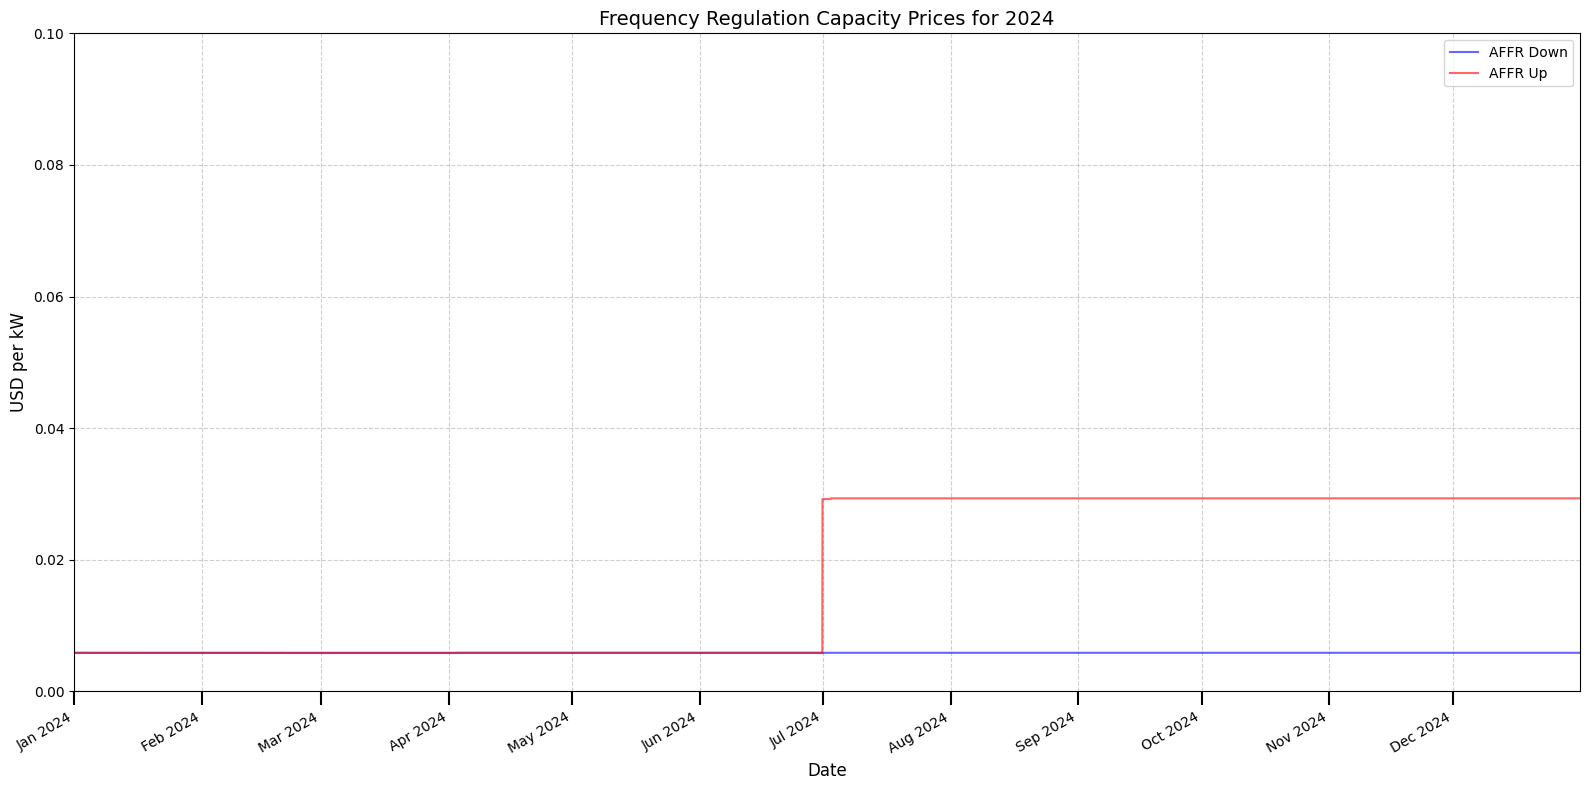

In [15]:
#aFFR (automatic frequency restoration reserve)

affr_down_df = pd.read_csv(f"{DATA_DIR}/aFRR_timeseries_down_8784_usd_per_kw.csv", header = None)

affr_down_df.index = affr_down_df.index.map(hour_to_datetime_dict)

affr_up_df = pd.read_csv(f"{DATA_DIR}/aFRR_timeseries_up_8784_usd_per_kw.csv", header = None)

affr_up_df.index = affr_up_df.index.map(hour_to_datetime_dict)

plt.figure(figsize=(16, 8))

plt.title("Frequency Regulation Capacity Prices for 2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("USD per kW", fontsize=12)
plt.ylim(0.0, 0.1)
plt.xlim(affr_up_df.index.min(), affr_up_df.index.max())

plt.plot(affr_down_df.index, affr_down_df.iloc[:,0], alpha=0.6, label="AFFR Down", color = "blue")
plt.plot(affr_up_df.index, affr_up_df.iloc[:,0], alpha=0.6, label="AFFR Up", color = "red")

# --- X-Axis Customization with Sub-Markings ---
ax = plt.gca()

# 1. Major Ticks: Every Month (with text labels)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Styling the ticks so you can distinguish them
ax.tick_params(axis='x', which='major', length=10, width=1.5, colors='black') # Longer, thicker major ticks

plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.legend(loc="best", fontsize=10, frameon=True)

plt.gcf().autofmt_xdate() 
plt.tight_layout()
plt.show()

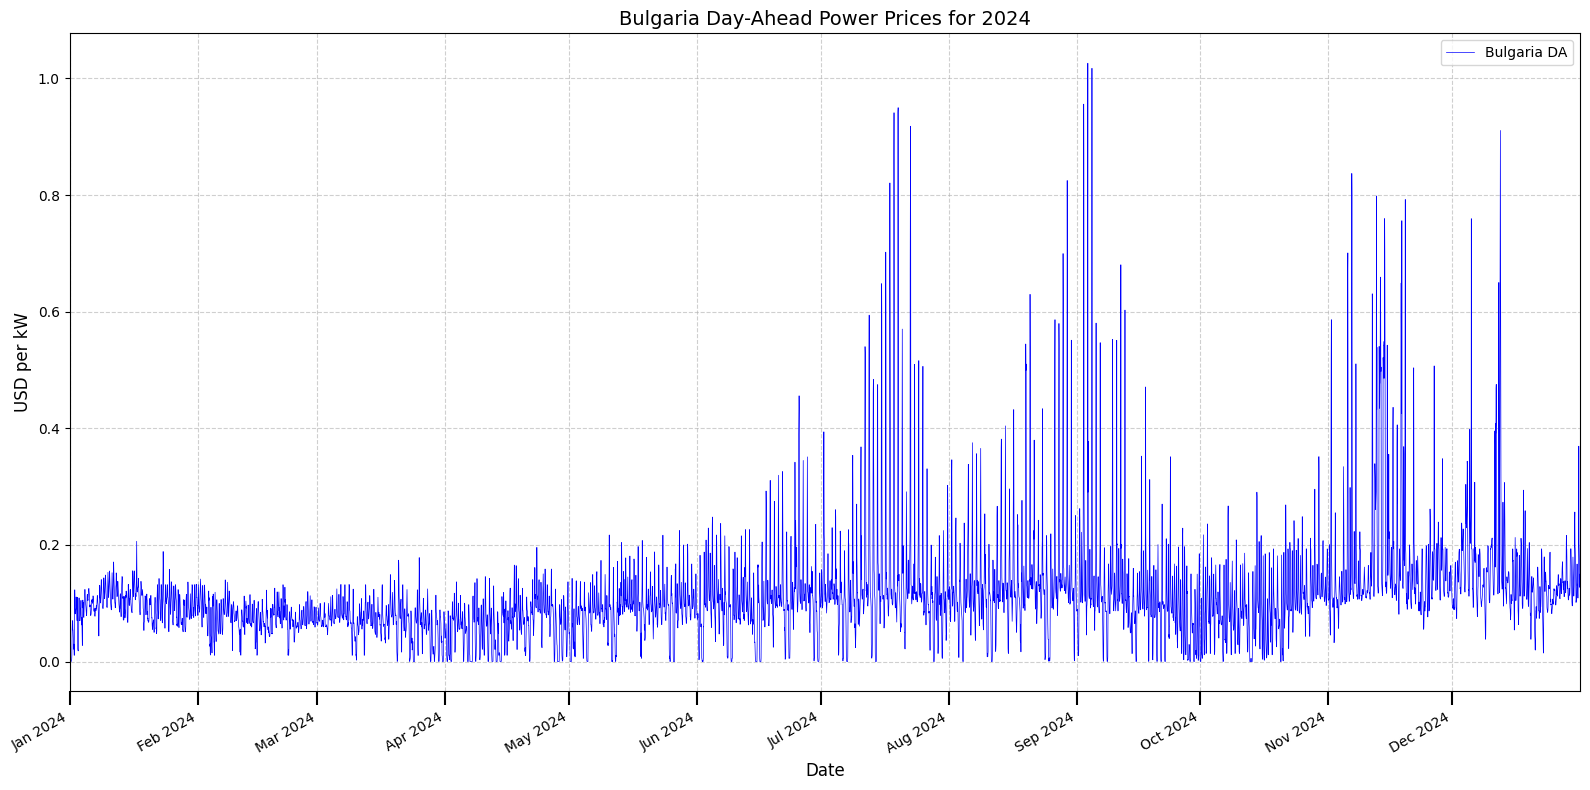

In [16]:
# Bulgaria Day Ahead Prices

DA_df = pd.read_csv(f"{DATA_DIR}/Bulgaria_day_ahead_price_2024_usd_per_kwh_clipped.csv", header = None)

DA_df.index = DA_df.index.map(hour_to_datetime_dict)

plt.figure(figsize=(16, 8))

plt.title("Bulgaria Day-Ahead Power Prices for 2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("USD per kW", fontsize=12)

plt.plot(DA_df.index, DA_df.iloc[:,0], alpha=1, label="Bulgaria DA", color = "blue", linewidth=0.5)
plt.xlim(DA_df.index.min(), DA_df.index.max())

# --- X-Axis Customization with Sub-Markings ---
ax = plt.gca()

# 1. Major Ticks: Every Month (with text labels)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Styling the ticks so you can distinguish them
ax.tick_params(axis='x', which='major', length=10, width=1.5, colors='black') # Longer, thicker major ticks

plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.legend(loc="best", fontsize=10, frameon=True)

plt.gcf().autofmt_xdate() 
plt.tight_layout()
plt.show()

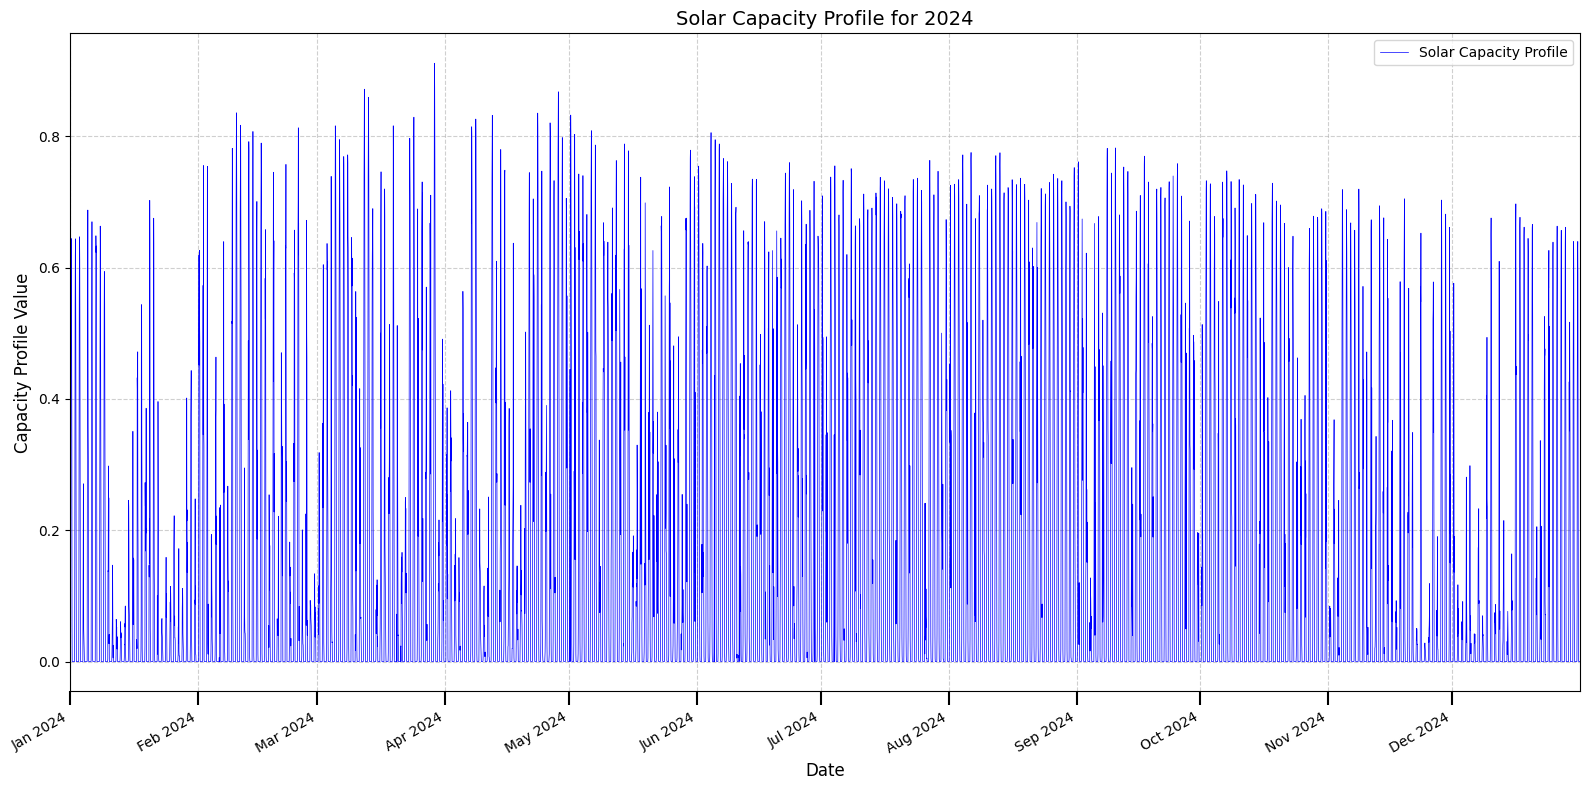

In [17]:
# Solar Profile data

solar_df = pd.read_csv(f"{DATA_DIR}/solar_profile_2024_pu.csv", header = None)

solar_df.index = solar_df.index.map(hour_to_datetime_dict)

plt.figure(figsize=(16, 8))

plt.title("Solar Capacity Profile for 2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Capacity Profile Value", fontsize=12)

plt.plot(solar_df.index, solar_df.iloc[:,0], alpha=1, label="Solar Capacity Profile", color = "blue", linewidth=0.5)
plt.xlim(solar_df.index.min(), solar_df.index.max())

# --- X-Axis Customization with Sub-Markings ---
ax = plt.gca()

# 1. Major Ticks: Every Month (with text labels)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Styling the ticks so you can distinguish them
ax.tick_params(axis='x', which='major', length=10, width=1.5, colors='black') # Longer, thicker major ticks

plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.legend(loc="best", fontsize=10, frameon=True)

plt.gcf().autofmt_xdate() 
plt.tight_layout()
plt.show()

#plt.xlim(solar_df.index.min(), solar_df.index.min() + timedelta(weeks = 1))


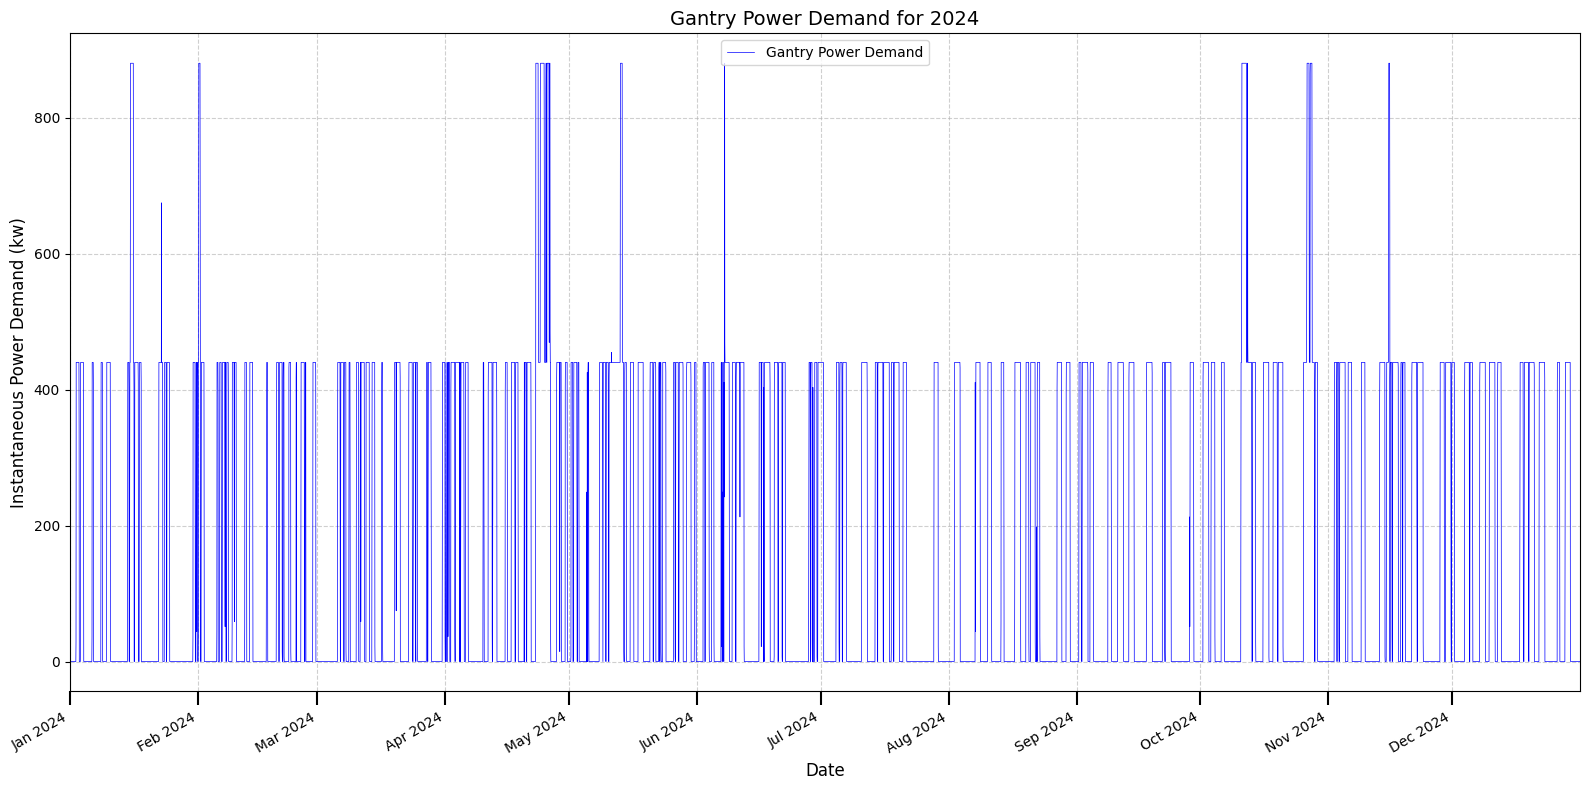

In [18]:
## Gantry power data

gantry_df = pd.read_csv(f"{DATA_DIR}/varna_container_gantry_power_hourly_2024_total_only.csv", header = None)

gantry_df.index = gantry_df.index.map(hour_to_datetime_dict)

plt.figure(figsize=(16, 8))

plt.title("Gantry Power Demand for 2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Instantaneous Power Demand (kw)", fontsize=12)

plt.plot(gantry_df.index, gantry_df.iloc[:,0], alpha=1, label="Gantry Power Demand", color = "blue", linewidth=0.5)
plt.xlim(gantry_df.index.min(), gantry_df.index.max())

# --- X-Axis Customization with Sub-Markings ---
ax = plt.gca()

# 1. Major Ticks: Every Month (with text labels)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Styling the ticks so you can distinguish them
ax.tick_params(axis='x', which='major', length=10, width=1.5, colors='black') # Longer, thicker major ticks

plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.legend(loc="best", fontsize=10, frameon=True)

plt.gcf().autofmt_xdate() 
plt.tight_layout()
plt.show()

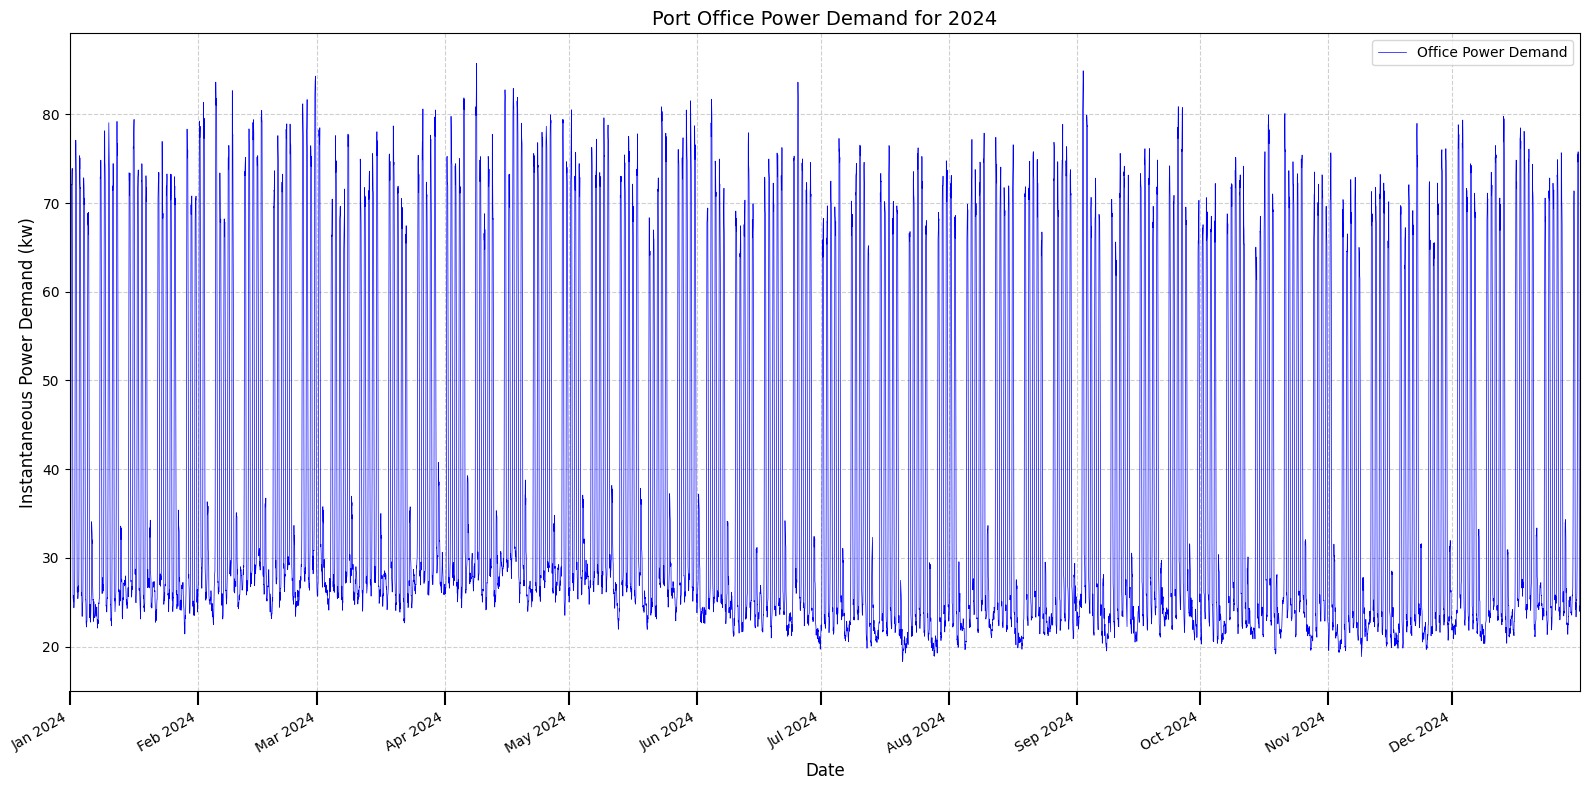

In [19]:
## Port office demand

office_df = pd.read_csv(f"{DATA_DIR}/varna_port_offices_kw_2024.csv", header = None)

office_df.index = office_df.index.map(hour_to_datetime_dict)

plt.figure(figsize=(16, 8))

plt.title("Port Office Power Demand for 2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Instantaneous Power Demand (kw)", fontsize=12)

plt.plot(office_df.index, office_df.iloc[:,0], alpha=1, label="Office Power Demand", color = "blue", linewidth=0.5)
plt.xlim(office_df.index.min(), office_df.index.max())

# --- X-Axis Customization with Sub-Markings ---
ax = plt.gca()

# 1. Major Ticks: Every Month (with text labels)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Styling the ticks so you can distinguish them
ax.tick_params(axis='x', which='major', length=10, width=1.5, colors='black') # Longer, thicker major ticks

plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.legend(loc="best", fontsize=10, frameon=True)

plt.gcf().autofmt_xdate() 
plt.tight_layout()
plt.show()

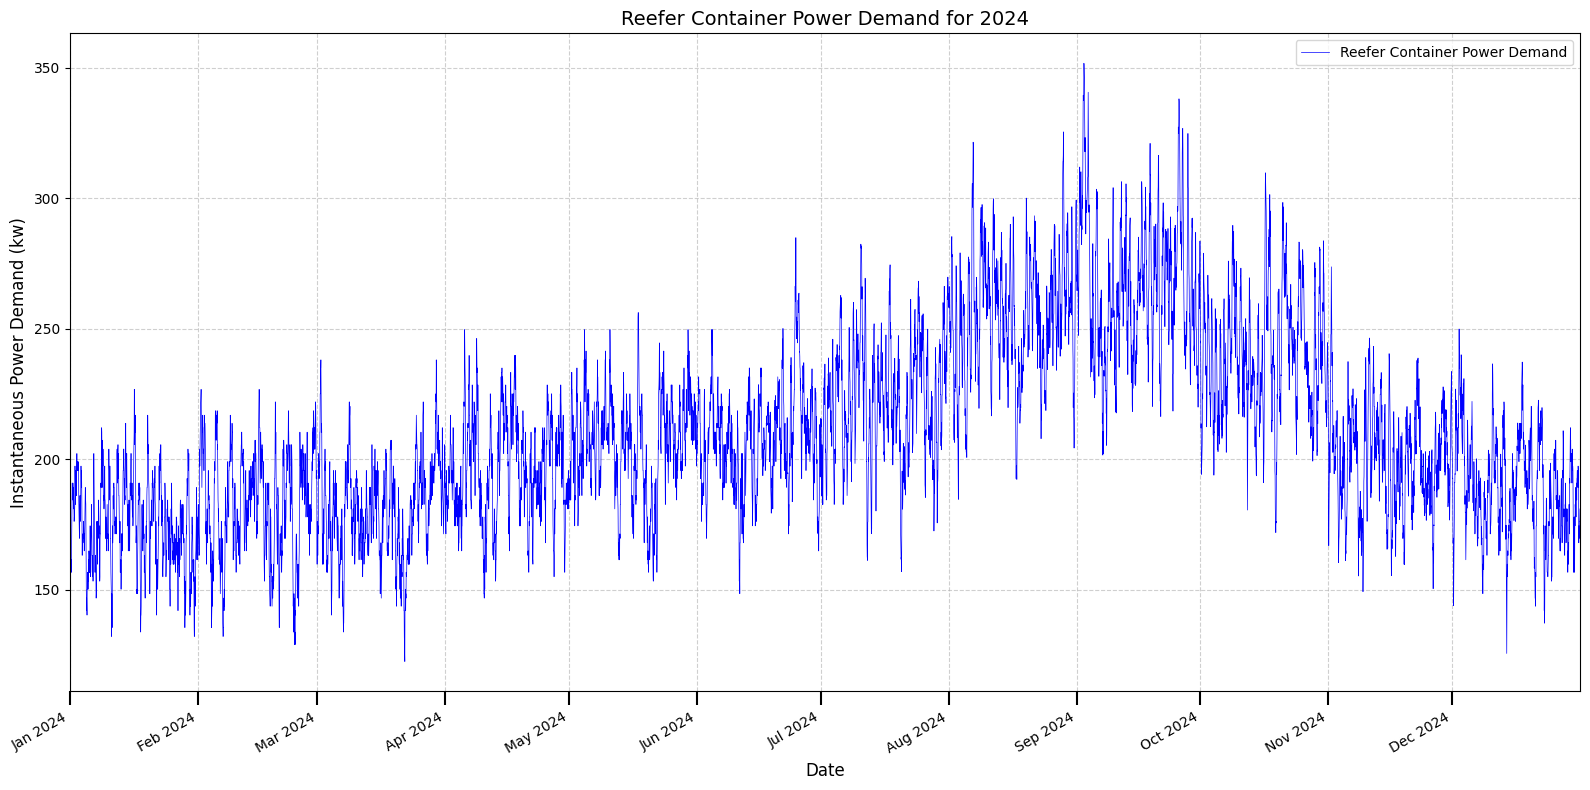

In [20]:
## Reefer container Demand

reefer_df = pd.read_csv(f"{DATA_DIR}/varna_reefer_timeseries_kW_2024.csv", header = None)

reefer_df.index = reefer_df.index.map(hour_to_datetime_dict)

plt.figure(figsize=(16, 8))

plt.title("Reefer Container Power Demand for 2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Instantaneous Power Demand (kw)", fontsize=12)

plt.plot(reefer_df.index, reefer_df.iloc[:,0], alpha=1, label="Reefer Container Power Demand", color = "blue", linewidth=0.5)
plt.xlim(reefer_df.index.min(), reefer_df.index.max())

# --- X-Axis Customization with Sub-Markings ---
ax = plt.gca()

# 1. Major Ticks: Every Month (with text labels)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Styling the ticks so you can distinguish them
ax.tick_params(axis='x', which='major', length=10, width=1.5, colors='black') # Longer, thicker major ticks

plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.legend(loc="best", fontsize=10, frameon=True)

plt.gcf().autofmt_xdate() 
plt.tight_layout()
plt.show()

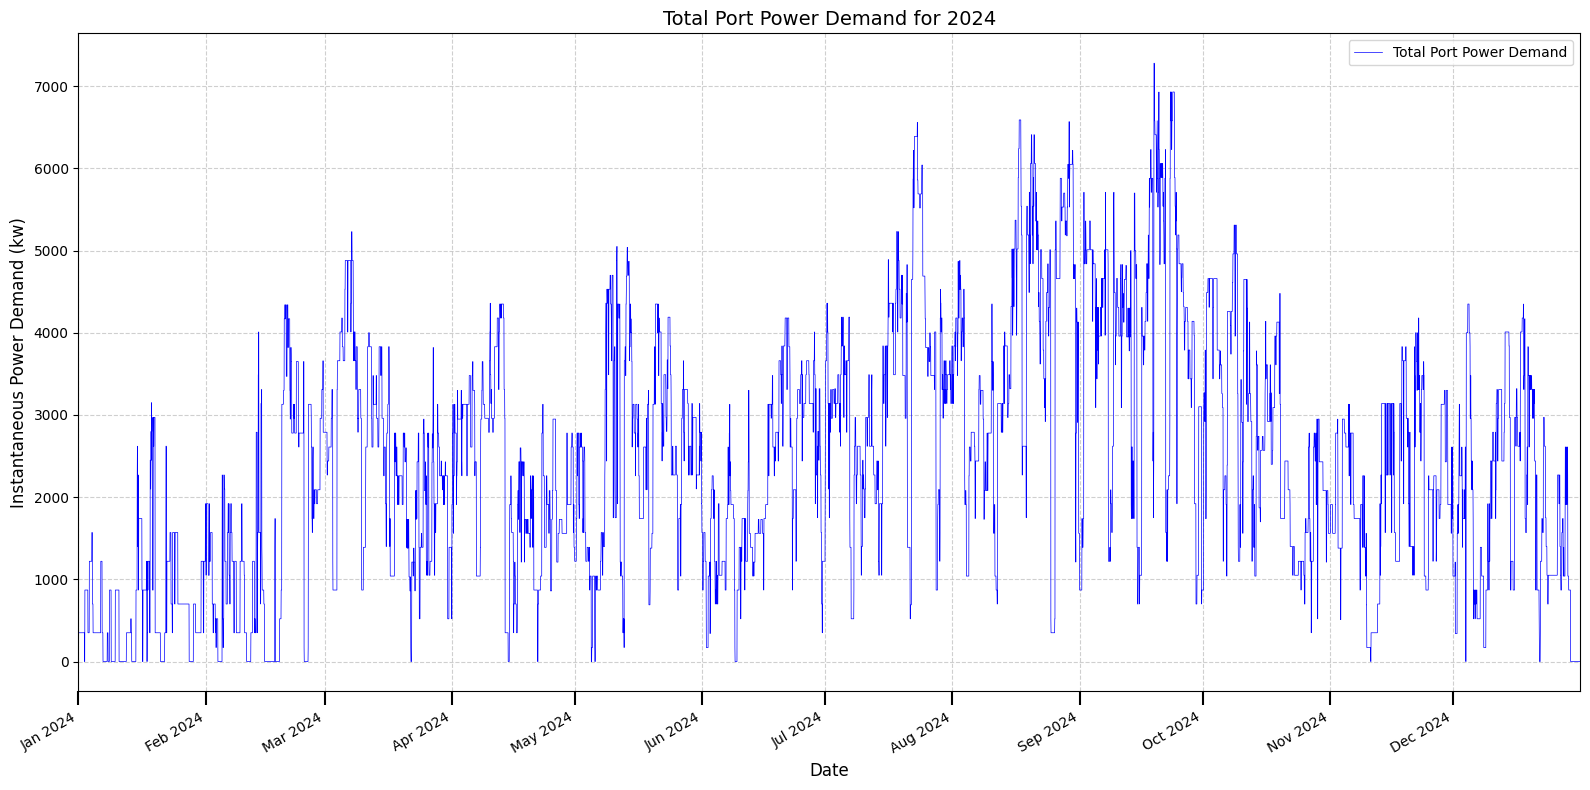

In [21]:
# Varna total annual hourly power demand

tot_dem_df = pd.read_csv(f"{DATA_DIR}/Varna_total_annual_hourly_kw_8784.csv", header = None)

tot_dem_df.index = tot_dem_df.index.map(hour_to_datetime_dict)

plt.figure(figsize=(16, 8))

plt.title("Total Port Power Demand for 2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Instantaneous Power Demand (kw)", fontsize=12)

plt.plot(tot_dem_df.index, tot_dem_df.iloc[:,0], alpha=1, label="Total Port Power Demand", color = "blue", linewidth=0.5)
plt.xlim(tot_dem_df.index.min(), tot_dem_df.index.max())

# --- X-Axis Customization with Sub-Markings ---
ax = plt.gca()

# 1. Major Ticks: Every Month (with text labels)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Styling the ticks so you can distinguish them
ax.tick_params(axis='x', which='major', length=10, width=1.5, colors='black') # Longer, thicker major ticks

plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.legend(loc="best", fontsize=10, frameon=True)

plt.gcf().autofmt_xdate() 
plt.tight_layout()
plt.show()